In [45]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # --------------------------------------------------------

    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [46]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [47]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [48]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [49]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    = 1e-5

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 1.0554722545756852
State dimension     = (256,)
Norm                = 1.0


In [50]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [51]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [52]:
# ============================================================
# Hamiltonian Variational Ansatz (HVA) VQE
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import L_BFGS_B

# ============================================================
# Physics-Inspired HVA for Scalar Field Hamiltonian
# ============================================================

def grouped_hva_asymm(nq, layers):

    qc = QuantumCircuit(nq)

    # --------------------------------------------------------
    # Tiny symmetry-breaking seed
    # --------------------------------------------------------

    for q in range(nq):
        qc.ry(0.01, q)

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    nparams_per_layer = 2 * nq + 1

    params = ParameterVector(
    "θ",
    nparams_per_layer * layers
    )

    p = 0

    for l in range(layers):
        offset = l * nparams_per_layer
        θx = params[offset : offset + nq]
        

        θz = params[offset + nq : offset + 2 * nq]

        

        θzz = params[offset + 2 * nq]
        

        # ----------------------------------------------------
        # X sector
        # exp(-i θ Σ X)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rx(2 * θx[q], q)

        # ----------------------------------------------------
        # Z sector
        # exp(-i θ Σ Z)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rz(2 * θz[q], q)

        # ----------------------------------------------------
        # ZZ sector
        # exp(-i θ Σ ZZ)
        # ----------------------------------------------------

        # Even bonds
        for q in range(0, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        # Odd bonds
        for q in range(1, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        p += 3

    return qc




In [53]:
# ============================================================
# Hamiltonian Variational Ansatz (HVA) VQE
# ============================================================

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector

from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import L_BFGS_B

# ============================================================
# Physics-Inspired HVA for Scalar Field Hamiltonian
# ============================================================

def grouped_hva_symm(nq, layers):

    qc = QuantumCircuit(nq)

    # --------------------------------------------------------
    # Tiny symmetry-breaking seed
    # --------------------------------------------------------

    for q in range(nq):
        qc.ry(0.01, q)

    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    nparams_per_layer = 2 * nq + 1

    params = ParameterVector(
    "θ",
    nparams_per_layer * layers
    )

    p = 0

    for l in range(layers):
        offset = l * nparams_per_layer
        θx = params[offset : offset + nq]
        

        θz = params[offset + nq : offset + 2 * nq]

        

        θzz = params[offset + 2 * nq]
        

        # ----------------------------------------------------
        # X sector
        # exp(-i θ Σ X)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rx(2 * θx[q], q)

        # ----------------------------------------------------
        # Z sector
        # exp(-i θ Σ Z)
        # ----------------------------------------------------

        for q in range(nq):
            qc.rz(2 * θz[q], q)

        # ----------------------------------------------------
        # ZZ sector
        # exp(-i θ Σ ZZ)
        # ----------------------------------------------------

        # Even bonds
        for q in range(0, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        # Odd bonds
        for q in range(1, nq - 1, 2):

            qc.cx(q, q + 1)
            qc.rz(2 * θzz, q + 1)
            qc.cx(q, q + 1)

        p += 3

    return qc




In [54]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state from sparse Hamiltonian
# ============================================================

from scipy.sparse.linalg import eigsh


def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [55]:
##### Fidelity Function

def fidelity(psi_exact, psi_vqe):

    return np.abs(np.vdot(psi_exact, psi_vqe))**2

In [56]:
# ============================================================
# Multi-parameter scan
# HVA + warm-start continuation + overlap tracking
# ============================================================

from qiskit.quantum_info import Statevector
from qiskit_algorithms.optimizers import L_BFGS_B

# ------------------------------------------------------------
# Fixed parameters
# ------------------------------------------------------------

nq_site = 4
nqubits = 2 * nq_site

mu = 1.0

# Default depth
layers = 8

# ------------------------------------------------------------
# Number of VQE restarts
# ------------------------------------------------------------

n_restarts = 5

# ------------------------------------------------------------
# Energy tolerance
# ------------------------------------------------------------

energy_tol = 1e-3

# ------------------------------------------------------------
# Parameter sets
# ------------------------------------------------------------

parameter_sets = [

    {
        "label": "Symmetric",
        "mI2": 1.0,
        "f": 0.0
    },

    {
        "label": "Weak SSB",
        "mI2": -1.0,
        "f": 1e-5
    },

    {
        "label": "Strong SSB",
        "mI2": -1.0,
        "f": 0.5
    }
]

# ------------------------------------------------------------
# Lambda values
# ------------------------------------------------------------

lambda_list = np.linspace(0.1, 2.0, 10)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

all_results = []

# ============================================================
# Main loop
# ============================================================

for params in parameter_sets:

    label = params["label"]
    mI2 = params["mI2"]
    f = params["f"]

    print("\n")
    print("#" * 80)
    print(f"CASE: {label}")
    print(f"mI² = {mI2},  f = {f}")
    print("#" * 80)

    case_results = []

    # --------------------------------------------------------
    # Tracking variables
    # --------------------------------------------------------

    previous_state = None
    previous_optimal_point = None

    # ========================================================
    # Lambda loop
    # ========================================================

    for lam in lambda_list:

        print("\n" + "=" * 60)
        print(f"Running λ = {lam:.3f}")
        print("=" * 60)

        # ----------------------------------------------------
        # Build H_loc
        # ----------------------------------------------------

        Hloc_sparse = two_site_hloc(
            nq=nq_site,
            mu=mu,
            mI2=mI2,
            lam=lam,
            f=f
        )

        # ----------------------------------------------------
        # Exact ground state
        # ----------------------------------------------------

        E_exact, psi_exact = exact_ground_state(
            Hloc_sparse
        )

        # ----------------------------------------------------
        # Dense Hamiltonian
        # ----------------------------------------------------

        H_dense = Hloc_sparse.toarray()

        # ----------------------------------------------------
        # Convert to Pauli form
        # ----------------------------------------------------

        H_op = Operator(H_dense)

        H_pauli = SparsePauliOp.from_operator(
            H_op
        )

        # ----------------------------------------------------
        # Remove identity shift
        # ----------------------------------------------------

        coeffs = H_pauli.coeffs
        paulis = H_pauli.paulis

        new_coeffs = []
        new_paulis = []

        identity_shift = 0.0

        for p, c in zip(paulis, coeffs):

            if str(p) == 'I' * nqubits:

                identity_shift += np.real(c)

            else:

                new_paulis.append(p)
                new_coeffs.append(c)

        H_pauli_shifted = SparsePauliOp(
            new_paulis,
            coeffs=new_coeffs
        )

        # ====================================================
        # Adaptive depth near critical region
        # ====================================================

        

        # ====================================================
        # Ansatz
        # ====================================================

        if mI2 < 0:

            ansatz = grouped_hva_asymm(
                nq=nqubits,
                layers=layers
            )

        else:

            ansatz = grouped_hva_symm(
                nq=nqubits,
                layers=layers
            )

        # ----------------------------------------------------
        # Estimator
        # ----------------------------------------------------

        estimator = StatevectorEstimator()

        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer = L_BFGS_B(maxiter=1000)

        # ====================================================
        # Weak SSB:
        # warm-start + overlap tracking
        # ====================================================

        if mI2 < 0 :

            print(
                "\nRunning HVA-VQE "
                "with warm-start tracking...\n"
            )

            candidate_states = []

            # ------------------------------------------------
            # Multiple restarts
            # ------------------------------------------------

            for trial in range(n_restarts):

                print(f"\nRestart {trial}")

                # --------------------------------------------
                # Initial point
                # --------------------------------------------

                if (
                    trial == 0
                    and previous_optimal_point is not None
                ):

                    initial_point = (
                        previous_optimal_point
                    )

                else:

                    initial_point = (
                        0.01 * np.random.randn(
                            ansatz.num_parameters
                        )
                    )

                # --------------------------------------------
                # VQE
                # --------------------------------------------

                vqe = VQE(
                    estimator=estimator,
                    ansatz=ansatz,
                    optimizer=optimizer,
                    initial_point=initial_point
                )

                result = (
                    vqe.compute_minimum_eigenvalue(
                        H_pauli_shifted
                    )
                )

                # --------------------------------------------
                # Physical energy
                # --------------------------------------------

                E_trial = (
                    result.eigenvalue.real
                    + identity_shift
                )

                # --------------------------------------------
                # Trial circuit
                # --------------------------------------------

                qc_trial = (
                    ansatz.assign_parameters(
                        result.optimal_parameters
                    )
                )

                # --------------------------------------------
                # Trial state
                # --------------------------------------------

                psi_trial = (
                    Statevector.from_instruction(
                        qc_trial
                    ).data
                )

                # --------------------------------------------
                # Fidelity
                # --------------------------------------------

                fidelity_trial = np.abs(
                    np.vdot(
                        psi_exact,
                        psi_trial
                    )
                )**2

                # --------------------------------------------
                # Overlap tracking
                # --------------------------------------------

                if previous_state is None:

                    overlap = 1.0

                else:

                    overlap = np.abs(
                        np.vdot(
                            previous_state,
                            psi_trial
                        )
                    )**2

                print(
                    f"Energy   = {E_trial:.12f}"
                )

                print(
                    f"Fidelity = {fidelity_trial:.12f}"
                )

                print(
                    f"Overlap  = {overlap:.12f}"
                )

                # --------------------------------------------
                # Store candidate
                # --------------------------------------------

                candidate_states.append({

                    "energy": E_trial,
                    "state": psi_trial,
                    "result": result,
                    "fidelity": fidelity_trial,
                    "overlap": overlap

                })

            # ------------------------------------------------
            # Minimum energy
            # ------------------------------------------------

            min_energy = min(
                c["energy"]
                for c in candidate_states
            )

            # ------------------------------------------------
            # Low-energy manifold
            # ------------------------------------------------

            filtered_candidates = [

                c for c in candidate_states

                if (
                    c["energy"] - min_energy
                ) < energy_tol
            ]

            # ------------------------------------------------
            # Select maximum overlap
            # ------------------------------------------------

            best_candidate = max(

                filtered_candidates,

                key=lambda x: x["overlap"]

            )

            # ------------------------------------------------
            # Final selected state
            # ------------------------------------------------

            best_energy = (
                best_candidate["energy"]
            )

            best_state = (
                best_candidate["state"]
            )

            best_result = (
                best_candidate["result"]
            )

            best_fidelity = (
                best_candidate["fidelity"]
            )

            best_overlap = (
                best_candidate["overlap"]
            )

            # ------------------------------------------------
            # Update tracking variables
            # ------------------------------------------------

            previous_state = best_state.copy()

            previous_optimal_point = (
                best_result.optimal_point
            )

        # ====================================================
        # Symmetric + Strong SSB
        # ====================================================

        else:

            print(
                "\nRunning ordinary HVA-VQE...\n"
            )

            initial_point = (
                0.01 * np.random.randn(
                    ansatz.num_parameters
                )
            )

            vqe = VQE(
                estimator=estimator,
                ansatz=ansatz,
                optimizer=optimizer,
                initial_point=initial_point
            )

            result = (
                vqe.compute_minimum_eigenvalue(
                    H_pauli_shifted
                )
            )

            best_energy = (
                result.eigenvalue.real
                + identity_shift
            )

            optimal_circuit = (
                ansatz.assign_parameters(
                    result.optimal_parameters
                )
            )

            best_state = (
                Statevector.from_instruction(
                    optimal_circuit
                ).data
            )

            best_fidelity = np.abs(
                np.vdot(
                    psi_exact,
                    best_state
                )
            )**2

            best_overlap = 1.0

        # ====================================================
        # Final VQE data
        # ====================================================

        E_vqe = best_energy
        F = best_fidelity

        # ====================================================
        # Store results
        # ====================================================

        data = {

            "case": label,

            "lambda": lam,

            "mI2": mI2,

            "f": f,

            "E_exact": E_exact,

            "E_vqe": E_vqe,

            "error": abs(
                E_exact - E_vqe
            ),

            "fidelity": F,

            "tracking_overlap": best_overlap,

            "layers": layers_local
        }

        case_results.append(data)
        all_results.append(data)

        # ====================================================
        # Print
        # ====================================================

        print("\nFINAL SELECTED STATE")

        print(
            f"Exact energy     : "
            f"{E_exact:.12f}"
        )

        print(
            f"VQE energy       : "
            f"{E_vqe:.12f}"
        )

        print(
            f"Energy error     : "
            f"{abs(E_exact - E_vqe):.6e}"
        )

        print(
            f"Fidelity         : "
            f"{F:.12f}"
        )

        print(
            f"Tracking overlap : "
            f"{best_overlap:.12f}"
        )

        print(
            f"Layers            : "
            f"{layers_local}"
        )

        print(
            f"Pauli terms       : "
            f"{len(H_pauli_shifted.paulis)}"
        )

    # ========================================================
    # Summary
    # ========================================================

    print("\n")
    print("=" * 140)
    print(f"SUMMARY : {label}")
    print("=" * 140)

    print(
        f"{'lambda':<12}"
        f"{'Exact E':<20}"
        f"{'VQE E':<20}"
        f"{'Error':<18}"
        f"{'Fidelity':<18}"
        f"{'TrackOverlap':<18}"
        f"{'Layers':<10}"
    )

    print("=" * 140)

    for r in case_results:

        print(
            f"{r['lambda']:<12.4f}"
            f"{r['E_exact']:<20.10f}"
            f"{r['E_vqe']:<20.10f}"
            f"{r['error']:<18.4e}"
            f"{r['fidelity']:<18.10f}"
            f"{r['tracking_overlap']:<18.10f}"
            f"{r['layers']:<10}"
        )



################################################################################
CASE: Symmetric
mI² = 1.0,  f = 0.0
################################################################################

Running λ = 0.100

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.006161728159
VQE energy       : 1.006162064066
Energy error     : 3.359071e-07
Fidelity         : 0.999999921365
Tracking overlap : 1.000000000000
Layers            : 8
Pauli terms       : 106

Running λ = 0.311

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.018641427347
VQE energy       : 1.018646972956
Energy error     : 5.545609e-06
Fidelity         : 0.999998971507
Tracking overlap : 1.000000000000
Layers            : 8
Pauli terms       : 108

Running λ = 0.522

Running ordinary HVA-VQE...


FINAL SELECTED STATE
Exact energy     : 1.030499309794
VQE energy       : 1.030509085129
Energy error     : 9.775335e-06
Fidelity         : 0.999998380819
Tracking overlap : 1.0000

In [57]:
print(all_results[0])

{'case': 'Symmetric', 'lambda': np.float64(0.1), 'mI2': 1.0, 'f': 0.0, 'E_exact': np.float64(1.006161728159068), 'E_vqe': np.float64(1.0061620640661868), 'error': np.float64(3.359071187869489e-07), 'fidelity': np.float64(0.9999999213648292), 'tracking_overlap': 1.0, 'layers': 8}


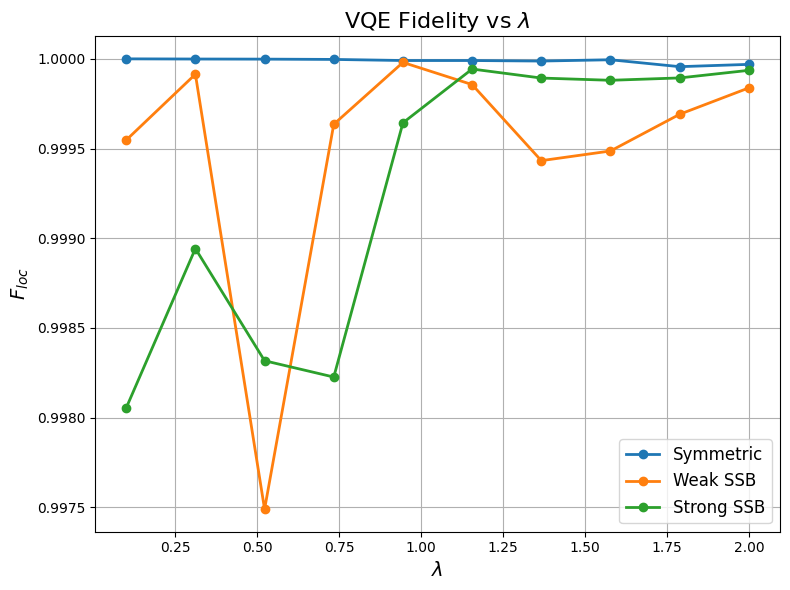

In [58]:
# ============================================================
# Plot : Fidelity vs lambda
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Collect data
# ------------------------------------------------------------

cases = {}

for r in all_results:

    label = r['case']

    if label not in cases:

        cases[label] = {
            'lambda': [],
            'fidelity': []
        }

    cases[label]['lambda'].append(r['lambda'])
    cases[label]['fidelity'].append(r['fidelity'])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

for label, data in cases.items():

    plt.plot(
        data['lambda'],
        data['fidelity'],
        marker='o',
        linewidth=2,
        label=label
    )

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel(r'$\lambda$', fontsize=14)

plt.ylabel(r'$F_{loc}$', fontsize=14)

plt.title(
    r'VQE Fidelity vs $\lambda$',
    fontsize=16
)

plt.grid(True)

plt.legend(fontsize=12)

plt.tight_layout()

plt.show()